# ENTRENAMIENTO DE RED NEURONAL PARA CLASIFICACIÓN DE AGUA POTABLE CON PYTORCH

## DATASET : [KAGGLE](https://www.kaggle.com/datasets/adityakadiwal/water-potability)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

# CARGAMOS EL DATASET

In [2]:
df = pd.read_csv('/content/water_potability.csv')
df.head(5)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


# EDA

In [3]:
df.dtypes

,0
ph,float64
Hardness,float64
Solids,float64
Chloramines,float64
Sulfate,float64
Conductivity,float64
Organic_carbon,float64
Trihalomethanes,float64
Turbidity,float64
Potability,int64


In [4]:
df.shape

(3276, 10)

In [5]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


# IMPUTACIÓN DE DATOS FALTANTES

In [6]:
for col in ['ph','Sulfate','Trihalomethanes']:
  df[col].fillna(df[col].median(),inplace=True)

df.isnull().sum()

<ipython-input-6-6e163149fcd5>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [7]:
df['Potability'].value_counts()

,count
Potability,
0,1998
1,1278


# CREAMOS VARIABLE DEPENDIENTE E INDEPENDIENTE

In [8]:
X = df.iloc[:,0:9].values
y = df.iloc[:,9].values

# ESCALAMIENTO DE DATOS

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# DIVIDIMOS DATASET EN ENTRENAMIENTO Y PRUEBA

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# CREAMOS RED NEURONAL CON TENSORFLOW Y KERAS

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
red = Sequential()
entrada = Dense(units=5,activation='relu')
oculta1 = Dense(units=5,activation='relu')
salida = Dense(units=1,activation='sigmoid')

red.add(entrada)
red.add(oculta1)
red.add(salida)

red

<Sequential name=sequential_1, built=False>

# CONFIGURAMOS LA RED CON UN OPTIMIZADOR

In [ ]:
red.compile(
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.01),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

# ENTRENAMOS LA RED NEURONAL

In [ ]:
model1 = red.fit(X_train,y_train,batch_size=30,epochs=100)

# VALIDAMOS EL MODELO

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

y_pred = red.predict(X_test)
y_pred = np.round(y_pred)

score = accuracy_score(y_test,y_pred)
print(f'el accuracy es {score}')

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
el accuracy es 0.663109756097561


# MATRIZ DE CONFUSIÓN

<Figure size 1100x1100 with 0 Axes>

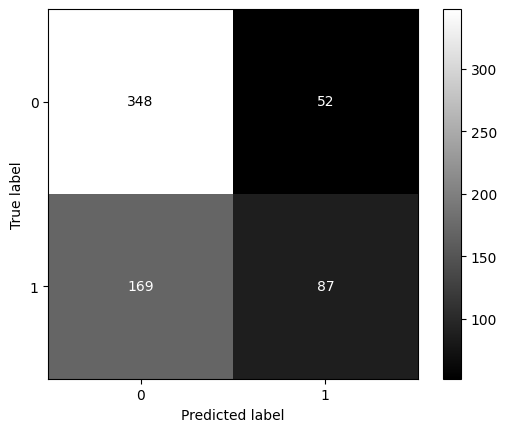

In [ ]:
matrix = confusion_matrix(y_test,y_pred)
fig = plt.figure(figsize=(11,11))
cm = matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='gray')
plt.show()

# CREAMOS RED NEURONAL CON PYTORCH

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim

class RNN(nn.Module):
  def __init__(self):
    super(RNN,self).__init__()
    #entrada = Dense(units=5,activation='relu')
    self.entrada = nn.Linear(9,5)
    #oculta1 = Dense(units=5,activation='relu')
    self.oculta1 = nn.Linear(5,5)
    #salida = Dense(units=1,activation='sigmoid')
    self.salida = nn.Linear(5,1)
    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  def forward(self,x):
    x = self.relu(self.entrada(x))
    x = self.relu(self.oculta1(x))
    x = self.sigmoid(self.salida(x))
    return x


# CONFIGURAMOS LA RED CON UN OPTIMIZADOR CON PYTORCH

In [19]:
modelo = RNN()
criterion = nn.BCELoss()
optimizer = optim.RMSprop(modelo.parameters(),lr=0.01)

# ENTRENAMOS LA RED NEURONAL CON PYTORCH

In [20]:
# Preparar los datos (asegúrate de que X_train y y_train sean tensores de PyTorch)
# Por ejemplo, si X_train y y_train son numpy arrays, conviértelos a tensores:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

In [21]:
epochs = 100
batch_size = 30
losses = []
accuracies = []

for epoch in range(epochs):
  modelo.train()
  running_loss = 0.0
  correct = 0

  for i in range(0,len(X_train_tensor),batch_size):
    #obtener el batch
    X_batch = X_train_tensor[i:i+batch_size]
    y_batch = y_train_tensor[i:i+batch_size].unsqueeze(1)

    #realizamos predicción
    ouputs = modelo(X_batch)

    #calculamos loss
    loss = criterion(ouputs,y_batch)
    running_loss += loss.item()

    #limpiamos los gradientes
    optimizer.zero_grad()

    #backprogration
    loss.backward()

    #actualizmaos los pesos
    optimizer.step()

  #calculamos la pérdida media y la precisión
  epoch_loss = running_loss / (len(X_train_tensor) / batch_size)
  losses.append(epoch_loss)

  #evaluamos el modelo en el conjunto de entrenamiento
  modelo.eval()
  with torch.no_grad():
    outpust = modelo(X_train_tensor)
    predicted = (outpust > 0.5).float()
    correct += (predicted.eq(y_train_tensor.unsqueeze(1))).sum().item()

  accuracy = correct / len(y_train_tensor)
  accuracies.append(accuracy)

  print(f'Epoch [{epoch + 1}/{epochs}], Loss : {epoch_loss:.4f} , Accuracy : {accuracy * 100:.2f}%')


Epoch [1/100], Loss : 0.6682 , Accuracy : 64.66%
Epoch [2/100], Loss : 0.6401 , Accuracy : 64.77%
Epoch [3/100], Loss : 0.6305 , Accuracy : 65.00%
Epoch [4/100], Loss : 0.6254 , Accuracy : 65.11%
Epoch [5/100], Loss : 0.6218 , Accuracy : 65.23%
Epoch [6/100], Loss : 0.6187 , Accuracy : 65.69%
Epoch [7/100], Loss : 0.6163 , Accuracy : 68.09%
Epoch [8/100], Loss : 0.6146 , Accuracy : 68.24%
Epoch [9/100], Loss : 0.6133 , Accuracy : 68.47%
Epoch [10/100], Loss : 0.6120 , Accuracy : 68.24%
Epoch [11/100], Loss : 0.6110 , Accuracy : 68.55%
Epoch [12/100], Loss : 0.6094 , Accuracy : 68.17%
Epoch [13/100], Loss : 0.6089 , Accuracy : 68.36%
Epoch [14/100], Loss : 0.6083 , Accuracy : 68.51%
Epoch [15/100], Loss : 0.6072 , Accuracy : 68.24%
Epoch [16/100], Loss : 0.6066 , Accuracy : 68.40%
Epoch [17/100], Loss : 0.6060 , Accuracy : 68.28%
Epoch [18/100], Loss : 0.6056 , Accuracy : 68.40%
Epoch [19/100], Loss : 0.6053 , Accuracy : 68.24%
Epoch [20/100], Loss : 0.6053 , Accuracy : 68.24%
Epoch [21

# GRAFICA DE ACCURACY Y LOSS DE ENTRENAMIENTO

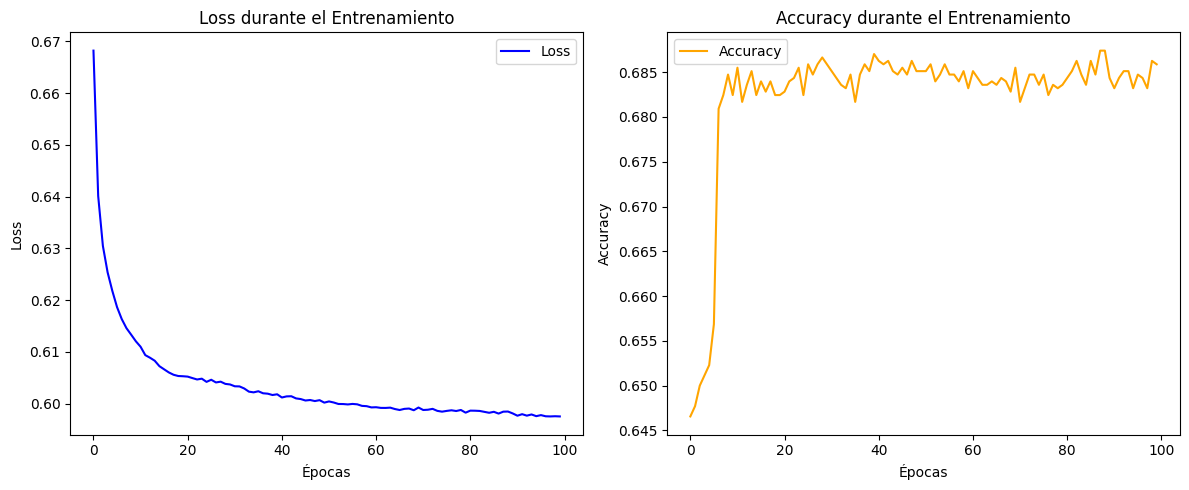

In [23]:
# Graficar loss y accuracy
plt.figure(figsize=(12, 5))

# Gráfica de Loss
plt.subplot(1, 2, 1)
plt.plot(losses, label='Loss', color='blue')
plt.title('Loss durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Gráfica de Accuracy
plt.subplot(1, 2, 2)
plt.plot(accuracies, label='Accuracy', color='orange')
plt.title('Accuracy durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# VALIDAMOS EL MODELO CON PYTORCH

In [22]:
#evaluamos el modelo en el conjunto de entrenamiento
modelo.eval()
with torch.no_grad():
  X_test_tensor = torch.tensor(X_test,dtype=torch.float32)
  y_test_tensor = torch.tensor(y_test,dtype=torch.float32).unsqueeze(1)

  test_outputs = modelo(X_test_tensor)
  predicted_test = (test_outputs > 0.5).float()
  correct_test = (predicted_test.eq(y_test_tensor)).sum().item()
  accuracy_test = correct_test / len(y_test_tensor)

print(f'Test Accuracy : {accuracy_test * 100:.2f}%')

Test Accuracy : 66.46%


# MATRIZ DE CONFUSIÓN

In [24]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
# Crear la matriz de confusión
y_test_labels = y_test_tensor.numpy()  # Convertir a numpy para sklearn
predicted_labels = predicted_test.numpy()  # Convertir a numpy para sklearn

cm = confusion_matrix(y_test_labels, predicted_labels)
cm

array([[331,  69],
       [151, 105]])

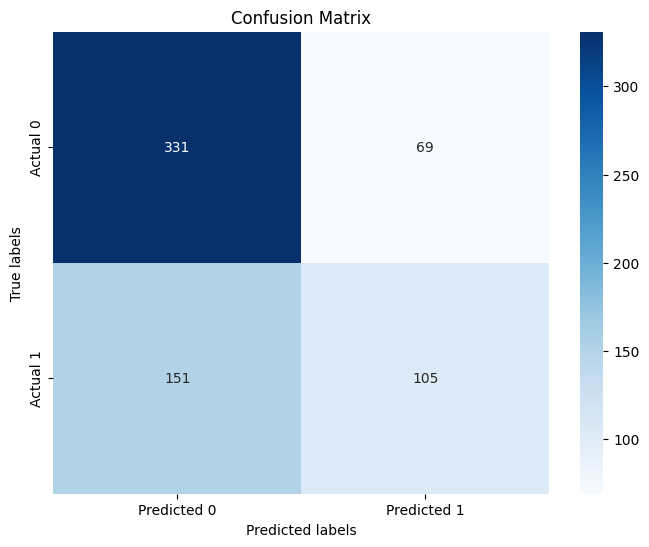

In [25]:
# Visualizar la matriz de confusión
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=['Predicted 0', 'Predicted 1'],
             yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()